In [1]:
import sys

sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import numpy as np
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

large_data_dir = gf_utils.large_data_dir

# load probe reads from cell line data

In [ ]:
manifest = pd.read_csv('../../1_figure_CL_proof_of_concept/data/manifest_gapfill_1plex.tsv', sep='\t')

manifest.loc[manifest['gap_probe_sequence'].isna(), 'name'] = manifest.loc[manifest['gap_probe_sequence'].isna(),'name'] + ' 0bp' ## annotate non-variant probes as 0bp
manifest['type'] = 'gapfill'
manifest.loc[manifest['name'].str.contains('0bp'),'type'] = '0bp_control'

gf_dir = large_data_dir + 'gf_CL3_HB_Betaine/BC1_giftwrap/'
adata_path = large_data_dir + 'CL3_HB_Betaine_0bp_genotype_GF.h5ad'

read_threshold = 20 ## very conservative because we don't want any effect of PCR chimeras

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold=read_threshold, min_percent_supporting=0.9, adata_path=adata_path)
probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start']], left_on='probe_idx',right_index=True, how='left')


9362534 UMIs found
Filtering probe reads based on read threshold (20) and min percent supporting (0.9), 7159784 UMIs remaining (76.47%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 6076443 UMIs remaining (64.90%)


# get ground truth genotypes

In [6]:
predicted_genotypes = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',sep=',')
predicted_genotypes.loc[predicted_genotypes['name'] == 'KRAS c.35G>*','name'] = 'KRAS c.34G>T'
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})

probe_reads = probe_reads.merge(predicted_genotypes.reset_index().melt(id_vars='name', var_name='cell_type', value_name='genotype'), on = ['name','cell_type'], how='left')
probe_reads = probe_reads.loc[probe_reads['genotype'].isin(['wt','mutated'])].reset_index(drop=True).copy()

probe_reads.loc[probe_reads['genotype'] == 'wt','expected_gapfill'] = probe_reads.loc[probe_reads['genotype'] == 'wt','gapfill_from_transcriptome']
probe_reads.loc[probe_reads['genotype'] == 'mutated','expected_gapfill'] = probe_reads.loc[probe_reads['genotype'] == 'mutated','gap_probe_sequence']

probe_reads = probe_reads.loc[probe_reads['name'] != 'HTT c.8157G>A'].copy() ### remove because we don't have confident ground truth

probe_reads = probe_reads.dropna(subset='expected_gapfill').reset_index(drop=True).copy()


# Get probabilities of each error type

[0.995758824087341, 0.003078871691109111, 0.00016828244366023278, 0.000897486975082152, 9.653480280755385e-05]


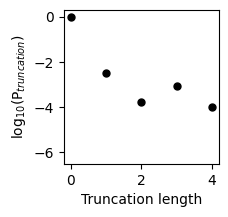

In [7]:
def p_lhs_truncated_gapfill(probe_reads,truncation_length):
    lhs_truncation = probe_reads['expected_gapfill'].apply(lambda x: x[truncation_length:] if len(x) >= truncation_length else np.nan)
    return (lhs_truncation == probe_reads['gapfill']).sum()/ lhs_truncation.notna().sum()
    
lengths = range(5)
probabilities = [p_lhs_truncated_gapfill(probe_reads, length) for length in lengths]
probabilities[0] = 1 - sum(probabilities[1:]) ## fix 0 entry to include all that are not LHS truncated (other errors are okay)

df = pd.DataFrame(probabilities, lengths).dropna()
plt.figure(figsize=(2,2))
plt.scatter(df.index, np.log10(df[0]), marker='o', s=25, color='k', zorder=5)
plt.xlabel('Truncation length')
plt.ylabel('log$_{10}$(P$_{truncation}$)')
plt.grid(False)
plt.ylim(-6.5, 0.3)
plt.savefig('../plots/LHS_truncation_probabilities.pdf', dpi=300, bbox_inches='tight')

print(probabilities)

[0.996592646840397, 0.0024261548756103974, 0.0001802314929142138, 0.0007225322637973275, 7.84345272811375e-05]


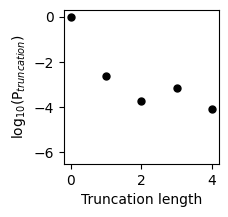

In [8]:
def p_rhs_truncated_gapfill(probe_reads, truncation_length):
    if truncation_length == 0:
        rhs_truncation = probe_reads['expected_gapfill']
    else:
        rhs_truncation = probe_reads['expected_gapfill'].apply(lambda x: x[:-truncation_length] if len(x) >= truncation_length else np.nan)
    return (rhs_truncation == probe_reads['gapfill']).sum()/ rhs_truncation.notna().sum()
    
lengths = range(5)
probabilities = [p_rhs_truncated_gapfill(probe_reads, length) for length in lengths]
probabilities[0] = 1 - sum(probabilities[1:]) ## fix 0 entry to include all that are not RHS truncated (other errors are okay)

df = pd.DataFrame(probabilities, lengths).dropna()
plt.figure(figsize=(2,2))
plt.scatter(df.index, np.log10(df[0]), marker='o', s=25, color='k', zorder=5)
plt.xlabel('Truncation length')
plt.ylabel('log$_{10}$(P$_{truncation}$)')
plt.grid(False)
plt.ylim(-6.5, 0.3)

plt.savefig('../plots/RHS_truncation_probabilities.pdf', dpi=300, bbox_inches='tight')

print(probabilities)


[0.9988076645212184, 0.001188211743816566, 1.4958624444785722e-06, 6.156786256082905e-07, 2.0121938950037227e-06]


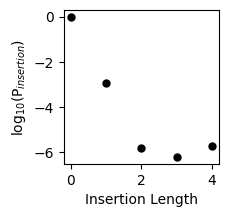

In [9]:
def p_lhs_gapfill_insertion(probe_reads, insertion_length):
    lhs_insertion = probe_reads['gapfill'].apply(lambda x: x[insertion_length:] if len(x) >= insertion_length else np.nan)
    return (lhs_insertion == probe_reads['expected_gapfill']).sum()/ lhs_insertion.notna().sum()

lengths = range(5)
probabilities = [p_lhs_gapfill_insertion(probe_reads, length) for length in lengths]
probabilities[0] = 1 - sum(probabilities[1:]) ## fix 0 entry to include all that are not insertion (other errors are okay)

df = pd.DataFrame(probabilities, lengths).dropna()
df = df.loc[df[0] > 0]

plt.figure(figsize=(2,2))
plt.scatter(df.index, np.log10(df[0]), marker='o', s=25, color='k', zorder=5)
plt.xlabel('Insertion Length')
plt.ylabel('log$_{10}$(P$_{insertion}$)')
plt.grid(False)
plt.ylim(-6.5, 0.3)

plt.savefig('../plots/LHS_insertion_probabilities.pdf', dpi=300, bbox_inches='tight')

print(probabilities)


[0.99800892093964, 0.001965905048679316, 2.2936557482004775e-05, 1.231357251216581e-06, 1.0060969475018613e-06]


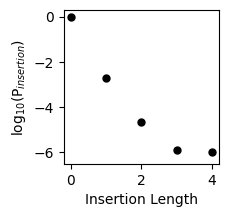

In [10]:
def p_rhs_gapfill_insertion(probe_reads, insertion_length):
    if insertion_length == 0:
        rhs_insertion = probe_reads['gapfill']
    else:
        rhs_insertion = probe_reads['gapfill'].apply(lambda x: x[:-insertion_length] if len(x) >= insertion_length else np.nan)
    return (rhs_insertion == probe_reads['expected_gapfill']).sum()/ rhs_insertion.notna().sum()

lengths = range(5)
probabilities = [p_rhs_gapfill_insertion(probe_reads, length) for length in lengths]
probabilities[0] = 1 - sum(probabilities[1:]) ## fix 0 entry to include all that are not insertion (other errors are okay)

df = pd.DataFrame(probabilities, lengths).dropna()
df = df.loc[df[0] > 0]
plt.figure(figsize=(2,2))
plt.scatter(df.index, np.log10(df[0]), marker='o', s=25, color='k', zorder=5)
plt.xlabel('Insertion Length')
plt.ylabel('log$_{10}$(P$_{insertion}$)')
plt.grid(False)
plt.ylim(-6.5, 0.3)

plt.savefig('../plots/RHS_insertion_probabilities.pdf', dpi=300, bbox_inches='tight')

print(probabilities)


hamming_distance
0.0    9.949649e-01
1.0    5.019837e-03
2.0    1.472266e-05
3.0    5.889063e-07
Name: proportion, dtype: float64


/tmp/ipykernel_3318457/872600462.py:12: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  probabilities[0] = 1 - sum(probabilities[1:]) ## fix 0 entry to include all that are not snv (other errors are okay)


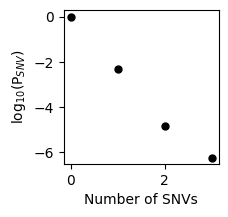

In [11]:
## get snv probabilities
probe_reads.loc[:, 'hamming_distance'] = probe_reads.apply(lambda row: sum(c1 != c2 for c1, c2 in zip(row['expected_gapfill'], row['gapfill'])), axis=1)

probe_reads.loc[probe_reads['gapfill'].str.len() != probe_reads['expected_gapfill'].str.len(), 'hamming_distance'] = None

### exclude variants because there can be pcr swaps
probes_to_include = probe_reads.groupby('probe_idx')['expected_gapfill'].nunique()
probes_to_include = probes_to_include[probes_to_include == 1].index
probe_reads.loc[~probe_reads['probe_idx'].isin(probes_to_include), 'hamming_distance'] = None

probabilities = probe_reads.loc[probe_reads['gapfill'].str.len() == probe_reads['expected_gapfill'].str.len()]['hamming_distance'].value_counts(normalize=True)
probabilities[0] = 1 - sum(probabilities[1:]) ## fix 0 entry to include all that are not snv (other errors are okay)

df = pd.DataFrame(probabilities, lengths).dropna()
plt.figure(figsize=(2,2))
plt.scatter(df.index, np.log10(df['proportion']), marker='o', s=25, color='k', zorder=5)
plt.xlabel('Number of SNVs')
plt.ylabel('log$_{10}$(P$_{SNV}$)')
plt.grid(False)
plt.ylim(-6.5, 0.3)

plt.savefig('../plots/snv_probabilities.pdf', dpi=300, bbox_inches='tight')

print(probabilities)
